In [2]:
pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 3.6 MB/s  0:00:033.7 MB/s eta 0:00:0104
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 9.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]━━━ 4/5 [prophet]]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded! ✅")

Libraries loaded! ✅


In [2]:
df = pd.read_csv('/Users/abhinavjha/NeuralRetail/data/processed/clean_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Data loaded: {df.shape} ✅")


Data loaded: (397924, 9) ✅


In [5]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])
print(f"Daily sales: {daily_sales.shape} ✅")
daily_sales.tail()

Daily sales: (305, 2) ✅


,ds,y
300,2011-12-05,58202.21
301,2011-12-06,46144.04
302,2011-12-07,69354.21
303,2011-12-08,50519.41
304,2011-12-09,184349.28


In [6]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(daily_sales)
print("Model trained! ✅")

09:18:40 - cmdstanpy - INFO - Chain [1] start processing
09:18:41 - cmdstanpy - INFO - Chain [1] done processing


Model trained! ✅


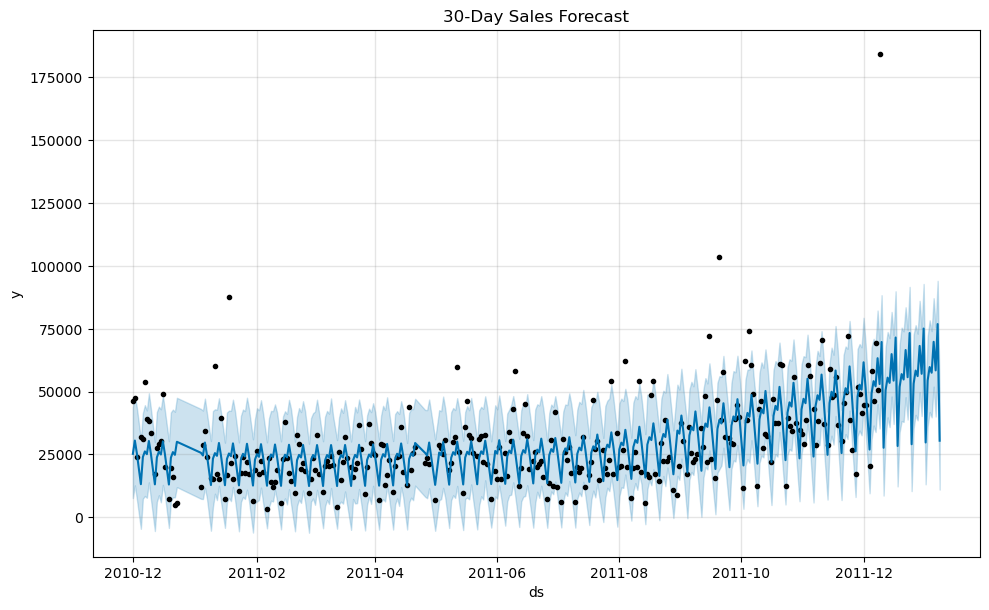

Forecast done! ✅


In [7]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.title('30-Day Sales Forecast')
plt.show()
print("Forecast done! ✅")
